<a href="https://colab.research.google.com/github/sayedarehmat6-dot/Regional_Phenotype_Gene_Transfer_Study/blob/main/Regional_Phenotype_Gene_Transfer_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

DATASET_NAME = "PAVS_cases.zip"
HPO_NAME = "hp-base.obo"

drive_root = Path("/content/drive")

dataset_matches = list(drive_root.rglob(DATASET_NAME))
hpo_matches = list(drive_root.rglob(HPO_NAME))

print("Dataset matches:")
for path in dataset_matches:
    print(path)

print("\nHPO ontology matches:")
for path in hpo_matches:
    print(path)

if len(dataset_matches) != 1:
    raise RuntimeError(
        f"Expected exactly one {DATASET_NAME}, found {len(dataset_matches)}"
    )

if len(hpo_matches) != 1:
    raise RuntimeError(
        f"Expected exactly one {HPO_NAME}, found {len(hpo_matches)}"
    )

DATASET_PATH = dataset_matches[0]
HPO_PATH = hpo_matches[0]

print("\nUsing:")
print("Dataset:", DATASET_PATH)
print("HPO:", HPO_PATH)

Dataset matches:
/content/drive/MyDrive/Regional_Phenotype_Gene_Transfer_Study/PAVS_cases.zip

HPO ontology matches:
/content/drive/MyDrive/Regional_Phenotype_Gene_Transfer_Study/hp-base.obo

Using:
Dataset: /content/drive/MyDrive/Regional_Phenotype_Gene_Transfer_Study/PAVS_cases.zip
HPO: /content/drive/MyDrive/Regional_Phenotype_Gene_Transfer_Study/hp-base.obo


In [2]:
from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/Regional_Phenotype_Gene_Transfer_Study"
)

FIGURES_DIR = RESULTS_DIR / "figures"
BMA_DIR = RESULTS_DIR / "bma_ontology_aware"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
BMA_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory:")
print(RESULTS_DIR)

Results directory:
/content/drive/MyDrive/Regional_Phenotype_Gene_Transfer_Study


In [ ]:
import zipfile
import pandas as pd

with zipfile.ZipFile(DATASET_PATH, "r") as z:

    tsv_files = [
        name
        for name in z.namelist()
        if name.lower().endswith(".tsv")
    ]

    print("TSV files inside ZIP:")
    for name in tsv_files:
        print(" -", name)

    if len(tsv_files) != 1:
        raise ValueError(
            f"Expected exactly one TSV inside the ZIP; found {tsv_files}"
        )

    tsv_name = tsv_files[0]

    with z.open(tsv_name) as f:
        df = pd.read_csv(
            f,
            sep="\t",
            low_memory=False
        )

print("\nDataset shape:", df.shape)

TSV files inside ZIP:
 - PAVS_cases (1).tsv

Dataset shape: (7510, 31)


In [ ]:
required_columns = {
    "case_id",
    "source",
    "solved_status",
    "gene_symbol",
    "hpo_terms"
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nCases by source:")

display(
    df["source"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

Number of rows: 7510
Number of columns: 31

Cases by source:


,n
source,
PAVS-Saudi,5132
DDD,1856
PAVS-mixed,522


In [ ]:
import re

HPO_PATTERN = re.compile(r"^HP:\d{7}$")

def parse_hpo_terms(value):

    if pd.isna(value):
        return []

    terms = []

    for item in str(value).split(";"):

        item = item.strip()

        if not item:
            continue

        hpo_id = item.split("|", 1)[0].strip()

        if HPO_PATTERN.fullmatch(hpo_id):
            terms.append(hpo_id)

    return sorted(set(terms))


df["hpo"] = df["hpo_terms"].apply(
    parse_hpo_terms
)

df["hpo_count"] = df["hpo"].apply(len)

print("Example parsed HPO annotations:")

display(
    df[
        [
            "case_id",
            "hpo_terms",
            "hpo",
            "hpo_count"
        ]
    ].head(10)
)

Example parsed HPO annotations:


,case_id,hpo_terms,hpo,hpo_count
0,PAVS:A0000001,HP:0001263|Global developmental delay;HP:00401...,"[HP:0000076, HP:0000126, HP:0001263, HP:0040189]",4
1,PAVS:A0000002,HP:0000787|Nephrolithiasis,[HP:0000787],1
2,PAVS:A0000003,HP:0001263|Global developmental delay;HP:00012...,"[HP:0000505, HP:0001250, HP:0001257, HP:000126...",7
3,PAVS:A0000004,HP:0000365|Hearing impairment,[HP:0000365],1
4,PAVS:A0000005,HP:0001290|Generalized hypotonia;HP:0002650|Sc...,"[HP:0000767, HP:0001252, HP:0001270, HP:000129...",7
5,PAVS:A0000006,HP:0000253|Progressive microcephaly;HP:0001250...,"[HP:0000253, HP:0001250, HP:0001272]",3
6,PAVS:A0000007,HP:0000505|Visual impairment;HP:0000646|Amblyo...,"[HP:0000505, HP:0000639, HP:0000646]",3
7,PAVS:A0000008,HP:0001973|Autoimmune thrombocytopenia;HP:0001...,"[HP:0001876, HP:0001973, HP:0002721]",3
8,PAVS:A0000009,HP:0000729|Autistic behavior;HP:0001249|Intell...,"[HP:0000729, HP:0000750, HP:0001249, HP:001243...",5
9,PAVS:A0000010,HP:0001263|Global developmental delay;HP:00005...,"[HP:0000486, HP:0000577, HP:0001263, HP:000206...",5


In [ ]:
eligible = (
    df["solved_status"].eq("SOLVED")
    &
    df["gene_symbol"].notna()
    &
    df["gene_symbol"].astype(str).str.strip().ne("")
    &
    (df["hpo_count"] >= 2)
)

saudi = df[
    eligible
    &
    df["source"].eq("PAVS-Saudi")
].copy()

ddd = df[
    eligible
    &
    df["source"].eq("DDD")
].copy()

saudi_gene_counts = (
    saudi["gene_symbol"]
    .value_counts()
)

retained_genes = saudi_gene_counts[
    saudi_gene_counts >= 5
].index

saudi = saudi[
    saudi["gene_symbol"].isin(
        retained_genes
    )
].reset_index(drop=True)

ddd = ddd.reset_index(drop=True)

print(
    "Eligible Saudi cases:",
    len(saudi)
)

print(
    "Eligible DDD cases:",
    len(ddd)
)

print(
    "Retained Saudi genes:",
    saudi["gene_symbol"].nunique()
)

print("\nSaudi HPO-count distribution:")

display(
    saudi["hpo_count"]
    .describe()
    .round(2)
    .to_frame("hpo_count")
)

Eligible Saudi cases: 511
Eligible DDD cases: 1437
Retained Saudi genes: 57

Saudi HPO-count distribution:


,hpo_count
count,511.00
mean,4.92
std,2.99
min,2.00
25%,3.00
50%,4.00
75%,7.00
max,26.00


In [ ]:
from sklearn.model_selection import StratifiedKFold

SEED = 42
N_FOLDS = 5

cv = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

fold_summary = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        saudi,
        saudi["gene_symbol"]
    ),
    start=1
):

    fold_summary.append({
        "fold": fold,
        "train_cases": len(train_idx),
        "test_cases": len(test_idx),
        "train_genes":
            saudi.iloc[
                train_idx
            ]["gene_symbol"].nunique(),
        "test_genes":
            saudi.iloc[
                test_idx
            ]["gene_symbol"].nunique()
    })

fold_summary = pd.DataFrame(
    fold_summary
)

display(fold_summary)

,fold,train_cases,test_cases,train_genes,test_genes
0,1,408,103,57,57
1,2,409,102,57,57
2,3,409,102,57,57
3,4,409,102,57,57
4,5,409,102,57,57


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

class PhenotypeGeneTFIDF:

    def __init__(self):

        self.vectorizer = TfidfVectorizer(
            token_pattern=r"[^ ]+"
        )

        self.genes = None
        self.profiles = None

    def fit(self, cases):

        texts = [
            " ".join(hpo_terms)
            for hpo_terms in cases["hpo"]
        ]

        X = (
            self.vectorizer
            .fit_transform(texts)
            .toarray()
        )

        self.genes = np.asarray(
            sorted(
                cases[
                    "gene_symbol"
                ].unique()
            ),
            dtype=object
        )

        gene_index = {
            gene: i
            for i, gene
            in enumerate(self.genes)
        }

        self.profiles = np.zeros(
            (
                len(self.genes),
                X.shape[1]
            ),
            dtype=float
        )

        for row, gene in zip(
            X,
            cases["gene_symbol"]
        ):

            self.profiles[
                gene_index[gene]
            ] += row

        norms = np.linalg.norm(
            self.profiles,
            axis=1,
            keepdims=True
        )

        self.profiles /= np.maximum(
            norms,
            1e-12
        )

    def rank(self, cases):

        texts = [
            " ".join(hpo_terms)
            for hpo_terms in cases["hpo"]
        ]

        X = (
            self.vectorizer
            .transform(texts)
            .toarray()
        )

        norms = np.linalg.norm(
            X,
            axis=1,
            keepdims=True
        )

        X /= np.maximum(
            norms,
            1e-12
        )

        scores = (
            X @ self.profiles.T
        )

        ranking = np.argsort(
            -scores,
            axis=1
        )

        ranks = []

        for i, target_gene in enumerate(
            cases["gene_symbol"].to_numpy()
        ):

            ranked_genes = (
                self.genes[
                    ranking[i]
                ]
            )

            hits = np.flatnonzero(
                ranked_genes == target_gene
            )

            if len(hits):

                ranks.append(
                    int(hits[0]) + 1
                )

            else:

                ranks.append(
                    np.nan
                )

        return ranks

In [ ]:
class GeneFrequencyModel:

    def fit(self, cases):

        counts = (
            cases["gene_symbol"]
            .value_counts()
        )

        self.genes = np.asarray(
            sorted(counts.index),
            dtype=object
        )

        self.counts = np.asarray([
            counts[gene]
            for gene in self.genes
        ])

    def rank(self, cases):

        order = np.argsort(
            -self.counts,
            kind="stable"
        )

        ranked_genes = (
            self.genes[order]
        )

        lookup = {
            gene: i + 1
            for i, gene
            in enumerate(ranked_genes)
        }

        return [
            lookup.get(
                gene,
                np.nan
            )
            for gene
            in cases["gene_symbol"]
        ]

In [ ]:
case_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        saudi,
        saudi["gene_symbol"]
    ),
    start=1
):

    print(
        f"Running fold {fold}/{N_FOLDS}"
    )

    train_saudi = (
        saudi.iloc[train_idx]
        .copy()
    )

    test_saudi = (
        saudi.iloc[test_idx]
        .copy()
    )

    # Match DDD training-set size
    # to the corresponding Saudi fold.

    ddd_train = ddd.sample(
        n=len(train_saudi),
        random_state=10000 + fold
    )

    saudi_model = (
        PhenotypeGeneTFIDF()
    )

    ddd_model = (
        PhenotypeGeneTFIDF()
    )

    saudi_frequency = (
        GeneFrequencyModel()
    )

    ddd_frequency = (
        GeneFrequencyModel()
    )

    saudi_model.fit(
        train_saudi
    )

    ddd_model.fit(
        ddd_train
    )

    saudi_frequency.fit(
        train_saudi
    )

    ddd_frequency.fit(
        ddd_train
    )

    saudi_rank = (
        saudi_model.rank(
            test_saudi
        )
    )

    ddd_rank = (
        ddd_model.rank(
            test_saudi
        )
    )

    saudi_frequency_rank = (
        saudi_frequency.rank(
            test_saudi
        )
    )

    ddd_frequency_rank = (
        ddd_frequency.rank(
            test_saudi
        )
    )

    for i, (_, case) in enumerate(
        test_saudi.iterrows()
    ):

        case_results.append({

            "fold": fold,

            "case_id":
                case["case_id"],

            "causal_gene":
                case["gene_symbol"],

            "hpo_count":
                int(case["hpo_count"]),

            "saudi_regional_rank":
                saudi_rank[i],

            "ddd_phenotype_rank":
                ddd_rank[i],

            "saudi_frequency_rank":
                saudi_frequency_rank[i],

            "ddd_frequency_rank":
                ddd_frequency_rank[i]
        })


primary_results = pd.DataFrame(
    case_results
)

primary_results.to_csv(
    RESULTS_DIR /
    "case_level_results.csv",
    index=False
)

print(
    "\nHeld-out cases:",
    len(primary_results)
)

display(
    primary_results.head()
)

Running fold 1/5
Running fold 2/5
Running fold 3/5
Running fold 4/5
Running fold 5/5

Held-out cases: 511


,fold,case_id,causal_gene,hpo_count,saudi_regional_rank,ddd_phenotype_rank,saudi_frequency_rank,ddd_frequency_rank
0,1,PAVS:A0000013,COG6,6,22,NaN,11,NaN
1,1,PAVS:A0000034,ARID1B,10,2,NaN,27,NaN
2,1,PAVS:A0000062,MECP2,3,5,NaN,12,NaN
3,1,PAVS:A0000076,SERAC1,8,1,NaN,51,NaN
4,1,PAVS:A0000100,TTN,5,1,24.0,18,340.0


In [ ]:
def calculate_metrics(series):

    ranks = pd.to_numeric(
        series,
        errors="coerce"
    ).to_numpy(dtype=float)

    finite = np.isfinite(ranks)

    safe_ranks = np.where(
        finite,
        ranks,
        np.inf
    )

    return {

        "n":
            len(ranks),

        "rankable_n":
            int(finite.sum()),

        "Recall@1_pct":
            np.mean(
                safe_ranks <= 1
            ) * 100,

        "Recall@5_pct":
            np.mean(
                safe_ranks <= 5
            ) * 100,

        "Recall@10_pct":
            np.mean(
                safe_ranks <= 10
            ) * 100,

        "Recall@20_pct":
            np.mean(
                safe_ranks <= 20
            ) * 100,

        "MRR":
            np.mean(
                np.where(
                    finite,
                    1 / ranks,
                    0
                )
            ),

        "MedianRank":
            (
                np.median(
                    ranks[finite]
                )
                if finite.any()
                else np.nan
            )
    }


conditions = {

    "Saudi regional phenotype":
        "saudi_regional_rank",

    "DDD phenotype":
        "ddd_phenotype_rank",

    "Saudi gene frequency":
        "saudi_frequency_rank",

    "DDD gene frequency":
        "ddd_frequency_rank"
}


aggregate_metrics = pd.DataFrame([

    {
        "condition": label,
        **calculate_metrics(primary_results[column])
    }

    for label, column
    in conditions.items()

])


display(
    aggregate_metrics.round(4)
)

aggregate_metrics.to_csv(
    RESULTS_DIR /
    "aggregate_metrics.csv",
    index=False
)

,condition,n,rankable_n,Recall@1_pct,Recall@5_pct,Recall@10_pct,Recall@20_pct,MRR,MedianRank
0,Saudi regional phenotype,511,511,53.0333,74.7554,83.5616,91.5851,0.6362,1.0
1,DDD phenotype,511,86,1.7613,4.6967,5.2838,7.8278,0.0310,23.5
2,Saudi gene frequency,511,511,5.4795,25.2446,41.2916,57.3386,0.1639,15.0
3,DDD gene frequency,511,86,0.0000,0.0000,0.1957,0.7828,0.0021,215.5


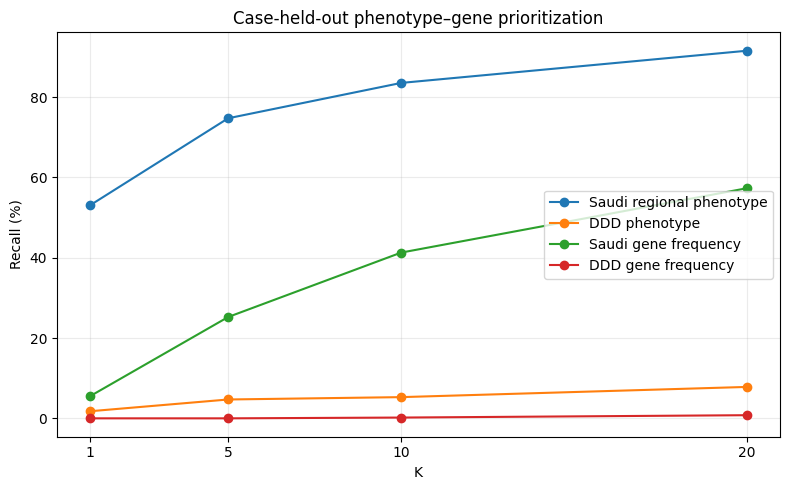

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(8, 5)
)

for label, column in conditions.items():

    ranks = pd.to_numeric(
        primary_results[column],
        errors="coerce"
    ).to_numpy(dtype=float)

    ranks = np.where(
        np.isfinite(ranks),
        ranks,
        np.inf
    )

    recall = [
        np.mean(
            ranks <= k
        ) * 100

        for k in [1, 5, 10, 20]
    ]

    ax.plot(
        [1, 5, 10, 20],
        recall,
        marker="o",
        label=label
    )

ax.set_xlabel("K")
ax.set_ylabel("Recall (%)")

ax.set_title(
    "Case-held-out phenotype–gene prioritization"
)

ax.set_xticks(
    [1, 5, 10, 20]
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "Figure_1_recall_and_controls.png",
    dpi=220
)

plt.show()

In [ ]:
joint = primary_results.dropna(
    subset=[
        "saudi_regional_rank",
        "ddd_phenotype_rank",
        "saudi_frequency_rank",
        "ddd_frequency_rank"
    ]
).copy()

print(
    "Jointly rankable cases:",
    len(joint)
)

joint_metrics = pd.DataFrame([

    {
        "condition": label,
        **calculate_metrics(joint[column])
    }

    for label, column
    in conditions.items()

])

display(
    joint_metrics.round(4)
)

joint_metrics.to_csv(
    RESULTS_DIR /
    "joint_rankable_metrics.csv",
    index=False
)

Jointly rankable cases: 86


,condition,n,rankable_n,Recall@1_pct,Recall@5_pct,Recall@10_pct,Recall@20_pct,MRR,MedianRank
0,Saudi regional phenotype,86,86,45.3488,67.4419,75.5814,84.8837,0.5688,2.0
1,DDD phenotype,86,86,10.4651,27.9070,31.3953,46.5116,0.1843,23.5
2,Saudi gene frequency,86,86,0.0000,4.6512,19.7674,45.3488,0.0657,22.5
3,DDD gene frequency,86,86,0.0000,0.0000,1.1628,4.6512,0.0124,215.5


In [ ]:
BOOTSTRAP_REPEATS = 20000

def paired_bootstrap(
    first,
    second,
    k,
    n=BOOTSTRAP_REPEATS,
    seed=42
):

    a = pd.to_numeric(
        first,
        errors="coerce"
    ).to_numpy(dtype=float)

    b = pd.to_numeric(
        second,
        errors="coerce"
    ).to_numpy(dtype=float)

    hit_a = a <= k
    hit_b = b <= k

    delta = (
        hit_a.astype(int)
        -
        hit_b.astype(int)
    )

    rng = np.random.default_rng(
        seed
    )

    indices = rng.integers(
        0,
        len(delta),
        size=(
            n,
            len(delta)
        )
    )

    bootstrap_values = (
        delta[indices]
        .mean(axis=1)
        * 100
    )

    return {

        "k": k,

        "n": len(delta),

        "difference_pp":
            delta.mean() * 100,

        "ci95_low_pp":
            np.quantile(
                bootstrap_values,
                0.025
            ),

        "ci95_high_pp":
            np.quantile(
                bootstrap_values,
                0.975
            )
    }


bootstrap_results = []

for k in [1, 5, 10, 20]:

    result = paired_bootstrap(
        joint[
            "saudi_regional_rank"
        ],
        joint[
            "ddd_phenotype_rank"
        ],
        k
    )

    bootstrap_results.append({

        "comparison":
            "regional_vs_ddd_phenotype",

        **result
    })

bootstrap_results = pd.DataFrame(
    bootstrap_results
)

display(
    bootstrap_results.round(4)
)

bootstrap_results.to_csv(
    RESULTS_DIR /
    "paired_bootstrap_regional_vs_ddd.csv",
    index=False
)

,comparison,k,n,difference_pp,ci95_low_pp,ci95_high_pp
0,regional_vs_ddd_phenotype,1,86,34.8837,24.4186,45.3488
1,regional_vs_ddd_phenotype,5,86,39.5349,26.7442,51.1628
2,regional_vs_ddd_phenotype,10,86,44.1860,31.3953,55.8140
3,regional_vs_ddd_phenotype,20,86,38.3721,25.5814,50.0000


In [ ]:
PERMUTATION_REPEATS = 20000

def paired_permutation_test(
    first,
    second,
    k,
    n=PERMUTATION_REPEATS,
    seed=42
):

    a = pd.to_numeric(
        first,
        errors="coerce"
    ).to_numpy(dtype=float)

    b = pd.to_numeric(
        second,
        errors="coerce"
    ).to_numpy(dtype=float)

    hit_a = (
        a <= k
    ).astype(int)

    hit_b = (
        b <= k
    ).astype(int)

    observed = np.mean(
        hit_a - hit_b
    )

    rng = np.random.default_rng(
        seed
    )

    extreme = 0

    for _ in range(n):

        swap = rng.integers(
            0,
            2,
            size=len(hit_a)
        ).astype(bool)

        perm_a = np.where(
            swap,
            hit_b,
            hit_a
        )

        perm_b = np.where(
            swap,
            hit_a,
            hit_b
        )

        statistic = np.mean(
            perm_a - perm_b
        )

        if statistic >= observed:
            extreme += 1

    p_value = (
        extreme + 1
    ) / (
        n + 1
    )

    return (
        observed * 100,
        p_value
    )


observed_difference, p_value = (
    paired_permutation_test(
        joint[
            "saudi_regional_rank"
        ],
        joint[
            "ddd_phenotype_rank"
        ],
        k=5
    )
)

print(
    f"Recall@5 difference: "
    f"{observed_difference:.2f} percentage points"
)

print(
    f"Paired permutation p-value: "
    f"{p_value:.5f}"
)

Recall@5 difference: 39.53 percentage points
Paired permutation p-value: 0.00005


In [ ]:
regional_rank = joint[
    "saudi_regional_rank"
]

ddd_rank = joint[
    "ddd_phenotype_rank"
]

direction = pd.DataFrame([{

    "joint_rankable_cases":
        len(joint),

    "regional_better_pct":
        (
            regional_rank
            <
            ddd_rank
        ).mean() * 100,

    "ddd_better_pct":
        (
            ddd_rank
            <
            regional_rank
        ).mean() * 100,

    "tie_pct":
        (
            regional_rank
            ==
            ddd_rank
        ).mean() * 100,

    "Recall@5_difference_pp":
        observed_difference,

    "paired_permutation_p":
        p_value

}])

display(
    direction.round(4)
)

direction.to_csv(
    RESULTS_DIR /
    "paired_direction_and_permutation.csv",
    index=False
)

,joint_rankable_cases,regional_better_pct,ddd_better_pct,tie_pct,Recall@5_difference_pp,paired_permutation_p
0,86,76.7442,12.7907,10.4651,39.5349,0.0


In [ ]:
sparse = primary_results[
    primary_results["hpo_count"] <= 5
].copy()

print(
    "Sparse phenotype cases:",
    len(sparse)
)

sparse_metrics = pd.DataFrame([

    {
        "condition": label,
        **calculate_metrics(sparse[column])
    }

    for label, column
    in conditions.items()

])

display(
    sparse_metrics.round(4)
)

sparse_metrics.to_csv(
    RESULTS_DIR /
    "sparse_hpo_metrics.csv",
    index=False
)

Sparse phenotype cases: 333


,condition,n,rankable_n,Recall@1_pct,Recall@5_pct,Recall@10_pct,Recall@20_pct,MRR,MedianRank
0,Saudi regional phenotype,333,333,50.7508,75.3754,83.1832,90.6907,0.6233,1.0
1,DDD phenotype,333,52,0.9009,5.1051,6.0060,7.8078,0.0266,21.0
2,Saudi gene frequency,333,333,2.1021,22.2222,41.7417,54.6547,0.1345,16.0
3,DDD gene frequency,333,52,0.0000,0.0000,0.0000,0.3003,0.0017,234.5


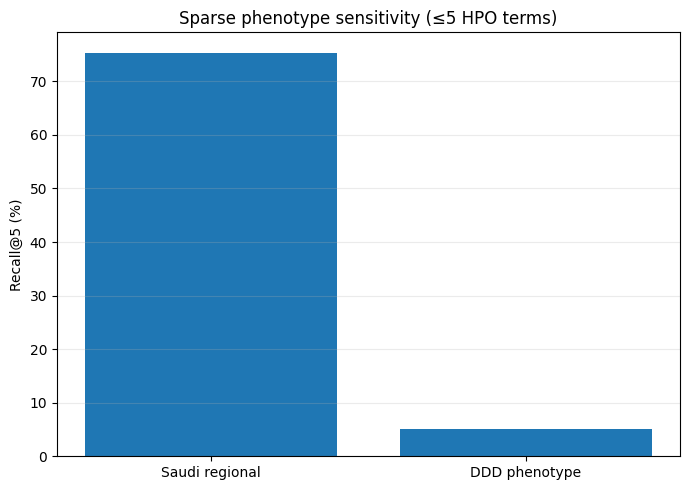

In [ ]:
plot_subset = sparse_metrics[
    sparse_metrics["condition"].isin([
        "Saudi regional phenotype",
        "DDD phenotype"
    ])
]

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    [
        "Saudi regional",
        "DDD phenotype"
    ],
    plot_subset["Recall@5_pct"]
)

ax.set_ylabel(
    "Recall@5 (%)"
)

ax.set_title(
    "Sparse phenotype sensitivity (≤5 HPO terms)"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "Figure_2_sparse_phenotype.png",
    dpi=220
)

plt.show()

In [ ]:
MATCH_REPEATS = 20

repeat_results = []

for repeat in range(
    1,
    MATCH_REPEATS + 1
):

    regional_ranks_all = []
    ddd_ranks_all = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(
            saudi,
            saudi["gene_symbol"]
        ),
        start=1
    ):

        train_saudi = (
            saudi.iloc[train_idx]
            .copy()
        )

        test_saudi = (
            saudi.iloc[test_idx]
            .copy()
        )

        ddd_train = ddd.sample(
            n=len(train_saudi),
            random_state=(
                100000
                + repeat * 10
                + fold
            )
        )

        regional_model = (
            PhenotypeGeneTFIDF()
        )

        ddd_model = (
            PhenotypeGeneTFIDF()
        )

        regional_model.fit(
            train_saudi
        )

        ddd_model.fit(
            ddd_train
        )

        regional_rank = (
            regional_model.rank(
                test_saudi
            )
        )

        ddd_rank = (
            ddd_model.rank(
                test_saudi
            )
        )

        regional_ranks_all.extend([
            r if np.isfinite(r)
            else np.inf
            for r in regional_rank
        ])

        ddd_ranks_all.extend([
            r if np.isfinite(r)
            else np.inf
            for r in ddd_rank
        ])

    repeat_results.append({

        "repeat": repeat,

        "regional_recall5_pct":
            np.mean(
                np.asarray(
                    regional_ranks_all
                ) <= 5
            ) * 100,

        "ddd_recall5_pct":
            np.mean(
                np.asarray(
                    ddd_ranks_all
                ) <= 5
            ) * 100
    })

repeat_results = pd.DataFrame(
    repeat_results
)

display(
    repeat_results.describe()
    .round(4)
)

repeat_results.to_csv(
    RESULTS_DIR /
    "ddd_size_match_sensitivity.csv",
    index=False
)

,repeat,regional_recall5_pct,ddd_recall5_pct
count,20.0000,20.0000,20.0000
mean,10.5000,74.7554,4.1292
std,5.9161,0.0000,1.0177
min,1.0000,74.7554,2.1526
25%,5.7500,74.7554,3.4247
50%,10.5000,74.7554,4.1096
75%,15.2500,74.7554,4.9413
max,20.0000,74.7554,5.6751


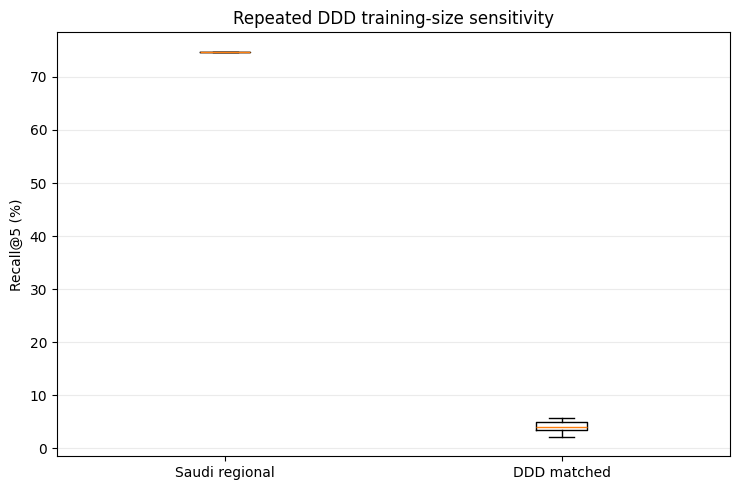

In [ ]:
fig, ax = plt.subplots(
    figsize=(7.5, 5)
)

ax.boxplot(
    [
        repeat_results[
            "regional_recall5_pct"
        ],

        repeat_results[
            "ddd_recall5_pct"
        ]
    ],

    tick_labels=[
        "Saudi regional",
        "DDD matched"
    ]
)

ax.set_ylabel(
    "Recall@5 (%)"
)

ax.set_title(
    "Repeated DDD training-size sensitivity"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "Figure_3_size_matched_sensitivity.png",
    dpi=220
)

plt.show()

In [ ]:
def parse_hpo_ontology(path):

    parents = {}
    alternative_ids = {}

    current_id = None

    with open(
        path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        for raw in f:

            line = raw.strip()

            if line == "[Term]":
                current_id = None

            elif line.startswith(
                "id: HP:"
            ):

                current_id = (
                    line
                    .split(
                        "id:",
                        1
                    )[1]
                    .strip()
                )

                parents.setdefault(
                    current_id,
                    set()
                )

            elif current_id:

                if line.startswith(
                    "is_a: HP:"
                ):

                    parent = (
                        line
                        .split(
                            "is_a:",
                            1
                        )[1]
                        .split(
                            "!",
                            1
                        )[0]
                        .strip()
                    )

                    parents[
                        current_id
                    ].add(parent)

                elif line.startswith(
                    "alt_id: HP:"
                ):

                    alternative = (
                        line
                        .split(
                            "alt_id:",
                            1
                        )[1]
                        .strip()
                    )

                    alternative_ids[
                        alternative
                    ] = current_id

    return (
        parents,
        alternative_ids
    )


parents, alternative_ids = (
    parse_hpo_ontology(HPO_PATH)
)

ancestor_cache = {}

def get_ancestors(term):

    term = alternative_ids.get(
        term,
        term
    )

    if term in ancestor_cache:
        return ancestor_cache[term]

    seen = {term}
    stack = [term]

    while stack:

        node = stack.pop()

        for parent in parents.get(
            node,
            set()
        ):

            parent = alternative_ids.get(
                parent,
                parent
            )

            if parent not in seen:

                seen.add(parent)
                stack.append(parent)

    ancestor_cache[term] = seen

    return seen


print(
    "HPO terms:",
    len(parents)
)

print(
    "Alternative IDs:",
    len(alternative_ids)
)

HPO terms: 20413
Alternative IDs: 3964


In [ ]:
def build_bma_profiles(training_cases):

    term_frequency = {}

    for hpo_terms in training_cases["hpo"]:

        expanded_terms = set()

        for term in hpo_terms:

            expanded_terms.update(
                get_ancestors(term)
            )

        for term in expanded_terms:

            term_frequency[term] = (
                term_frequency.get(
                    term,
                    0
                )
                + 1
            )

    n_cases = len(
        training_cases
    )

    information_content = {

        term:
            float(
                np.log(
                    (n_cases + 1)
                    /
                    (count + 1)
                )
            )

        for term, count
        in term_frequency.items()
    }

    genes = np.asarray(
        sorted(
            training_cases[
                "gene_symbol"
            ].unique()
        ),
        dtype=object
    )

    gene_profiles = {}

    for gene in genes:

        terms = set()

        gene_cases = training_cases[
            training_cases[
                "gene_symbol"
            ] == gene
        ]

        for hpo_terms in gene_cases["hpo"]:

            terms.update(
                hpo_terms
            )

        gene_profiles[gene] = sorted(
            terms
        )

    return (
        genes,
        gene_profiles,
        information_content
    )


def resnik_similarity(
    term_a,
    term_b,
    information_content,
    cache
):

    key = (
        term_a,
        term_b
    )

    if key not in cache:

        shared_ancestors = (
            get_ancestors(term_a)
            &
            get_ancestors(term_b)
        )

        cache[key] = max(
            [
                information_content.get(
                    term,
                    0.0
                )
                for term
                in shared_ancestors
            ],
            default=0.0
        )

    return cache[key]


def bma_score(
    case_terms,
    gene_terms,
    information_content,
    cache
):

    if (
        not case_terms
        or not gene_terms
    ):
        return 0.0

    case_to_gene = np.mean([

        max([

            resnik_similarity(
                case_term,
                gene_term,
                information_content,
                cache
            )

            for gene_term
            in gene_terms

        ], default=0.0)

        for case_term
        in case_terms

    ])

    gene_to_case = np.mean([

        max([

            resnik_similarity(
                gene_term,
                case_term,
                information_content,
                cache
            )

            for case_term
            in case_terms

        ], default=0.0)

        for gene_term
        in gene_terms

    ])

    return (
        case_to_gene
        +
        gene_to_case
    ) / 2

In [ ]:
bma_case_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        saudi,
        saudi["gene_symbol"]
    ),
    start=1
):

    print(
        f"BMA fold {fold}/{N_FOLDS}"
    )

    train = (
        saudi.iloc[train_idx]
        .copy()
    )

    test = (
        saudi.iloc[test_idx]
        .copy()
    )

    (
        genes,
        gene_profiles,
        information_content
    ) = build_bma_profiles(
        train
    )

    similarity_cache = {}

    for _, case in test.iterrows():

        gene_scores = {}

        for gene in genes:

            gene_scores[gene] = (
                bma_score(
                    case["hpo"],
                    gene_profiles[gene],
                    information_content,
                    similarity_cache
                )
            )

        ranked_genes = sorted(
            gene_scores,
            key=gene_scores.get,
            reverse=True
        )

        target = case[
            "gene_symbol"
        ]

        if target in ranked_genes:

            rank = (
                ranked_genes.index(
                    target
                )
                + 1
            )

        else:

            rank = np.nan

        bma_case_results.append({

            "fold": fold,

            "case_id":
                case["case_id"],

            "causal_gene":
                target,

            "hpo_count":
                int(case["hpo_count"]),

            "bma_rank":
                rank
        })


bma_results = pd.DataFrame(
    bma_case_results
)

bma_results.to_csv(
    BMA_DIR /
    "bma_case_level_results.csv",
    index=False
)

print(
    "BMA held-out cases:",
    len(bma_results)
)

display(
    bma_results.head()
)

BMA fold 1/5
BMA fold 2/5
BMA fold 3/5
BMA fold 4/5
BMA fold 5/5
BMA held-out cases: 511


,fold,case_id,causal_gene,hpo_count,bma_rank
0,1,PAVS:A0000013,COG6,6,10
1,1,PAVS:A0000034,ARID1B,10,5
2,1,PAVS:A0000062,MECP2,3,3
3,1,PAVS:A0000076,SERAC1,8,1
4,1,PAVS:A0000100,TTN,5,12


In [ ]:
bma_metrics = pd.DataFrame([

    {
        "condition":
            "Saudi BMA/Resnik",

        **calculate_metrics(
            bma_results[
                "bma_rank"
            ]
        )
    }

])

display(
    bma_metrics.round(4)
)

bma_metrics.to_csv(
    BMA_DIR /
    "bma_metrics.csv",
    index=False
)

,condition,n,rankable_n,Recall@1_pct,Recall@5_pct,Recall@10_pct,Recall@20_pct,MRR,MedianRank
0,Saudi BMA/Resnik,511,511,49.1194,70.4501,80.4305,90.998,0.5959,2.0


In [ ]:
BMA_PERMUTATIONS = 5000

negative_control_rows = []

rng = np.random.default_rng(
    SEED
)

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        saudi,
        saudi["gene_symbol"]
    ),
    start=1
):

    print(
        f"Negative-control fold "
        f"{fold}/{N_FOLDS}"
    )

    train = (
        saudi.iloc[train_idx]
        .copy()
    )

    test = (
        saudi.iloc[test_idx]
        .copy()
    )

    (
        genes,
        gene_profiles,
        information_content
    ) = build_bma_profiles(
        train
    )

    similarity_cache = {}

    score_matrix = np.zeros(
        (
            len(test),
            len(genes)
        )
    )

    for i, (_, case) in enumerate(
        test.iterrows()
    ):

        for j, gene in enumerate(
            genes
        ):

            score_matrix[
                i,
                j
            ] = bma_score(
                case["hpo"],
                gene_profiles[gene],
                information_content,
                similarity_cache
            )

    ranking = np.argsort(
        -score_matrix,
        axis=1
    )

    target_indices = np.array([

        np.where(
            genes == gene
        )[0][0]

        for gene
        in test["gene_symbol"]

    ])

    for permutation in range(
        1,
        BMA_PERMUTATIONS + 1
    ):

        permuted_targets = (
            rng.permutation(
                target_indices
            )
        )

        ranks = []

        for i, target_index in enumerate(
            permuted_targets
        ):

            position = np.where(
                ranking[i]
                ==
                target_index
            )[0][0]

            ranks.append(
                position + 1
            )

        ranks = np.asarray(
            ranks
        )

        negative_control_rows.append({

            "fold": fold,

            "permutation":
                permutation,

            "Recall@1_pct":
                np.mean(
                    ranks <= 1
                ) * 100,

            "Recall@5_pct":
                np.mean(
                    ranks <= 5
                ) * 100,

            "Recall@10_pct":
                np.mean(
                    ranks <= 10
                ) * 100,

            "Recall@20_pct":
                np.mean(
                    ranks <= 20
                ) * 100
        })


bma_negative_control = (
    pd.DataFrame(
        negative_control_rows
    )
)

bma_negative_control.to_csv(
    BMA_DIR /
    "bma_within_saudi_label_permutation_null.csv",
    index=False
)

display(
    bma_negative_control.head()
)

Negative-control fold 1/5
Negative-control fold 2/5
Negative-control fold 3/5
Negative-control fold 4/5
Negative-control fold 5/5


,fold,permutation,Recall@1_pct,Recall@5_pct,Recall@10_pct,Recall@20_pct
0,1,1,4.854369,15.533981,28.155340,45.631068
1,1,2,2.912621,9.708738,19.417476,41.747573
2,1,3,2.912621,13.592233,20.388350,38.834951
3,1,4,2.912621,10.679612,19.417476,34.951456
4,1,5,1.941748,7.766990,18.446602,34.951456


In [ ]:
observed_bma_recall5 = (
    np.mean(
        bma_results[
            "bma_rank"
        ] <= 5
    ) * 100
)

null_recall5 = (
    bma_negative_control[
        "Recall@5_pct"
    ].to_numpy(
        dtype=float
    )
)

empirical_p = (
    1
    +
    np.sum(
        null_recall5
        >=
        observed_bma_recall5
    )
) / (
    len(null_recall5)
    + 1
)

bma_null_summary = pd.DataFrame([{

    "metric":
        "Recall@5",

    "observed_pct":
        observed_bma_recall5,

    "null_mean_pct":
        null_recall5.mean(),

    "null_sd_pct":
        null_recall5.std(
            ddof=1
        ),

    "null_95th_percentile":
        np.quantile(
            null_recall5,
            0.95
        ),

    "null_99_5th_percentile":
        np.quantile(
            null_recall5,
            0.995
        ),

    "empirical_one_sided_p":
        empirical_p

}])

display(
    bma_null_summary.round(5)
)

bma_null_summary.to_csv(
    BMA_DIR /
    "bma_within_saudi_label_permutation_summary.csv",
    index=False
)

,metric,observed_pct,null_mean_pct,null_sd_pct,null_95th_percentile,null_99_5th_percentile,empirical_one_sided_p
0,Recall@5,70.4501,9.91031,2.93213,14.70588,17.64706,0.00004


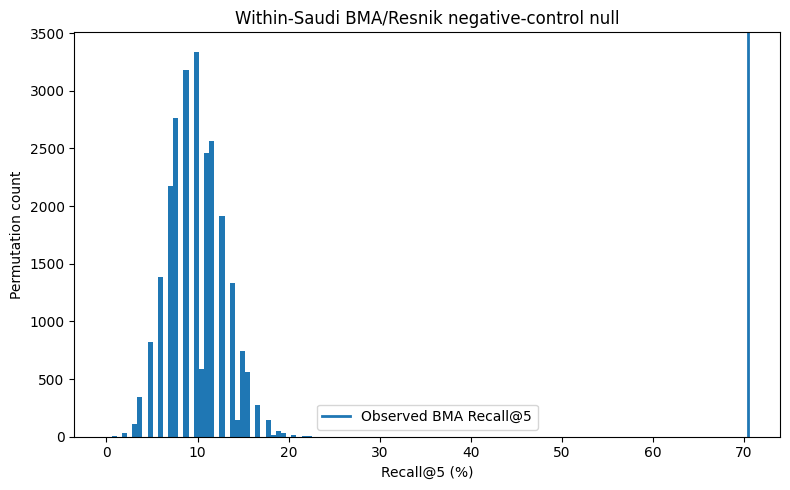

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    null_recall5,
    bins=40
)

ax.axvline(
    observed_bma_recall5,
    linewidth=2,
    label="Observed BMA Recall@5"
)

ax.set_xlabel(
    "Recall@5 (%)"
)

ax.set_ylabel(
    "Permutation count"
)

ax.set_title(
    "Within-Saudi BMA/Resnik negative-control null"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "Figure_4_bma_permutation_null.png",
    dpi=220
)

plt.show()

In [ ]:
import hashlib
import platform
import json

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            h.update(
                chunk
            )

    return h.hexdigest()


manifest = {

    "study":
        "Regional Phenotype-Gene Transfer Study",



    "seed":
        SEED,

    "folds":
        N_FOLDS,

    "minimum_cases_per_gene":
        MIN_CASES_PER_GENE if "MIN_CASES_PER_GENE" in globals() else 5,

    "bootstrap_repeats":
        BOOTSTRAP_REPEATS,

    "paired_permutation_repeats":
        PERMUTATION_REPEATS,

    "bma_label_permutations_per_fold":
        BMA_PERMUTATIONS,

    "dataset_filename":
        DATASET_PATH.name,

    "dataset_sha256":
        sha256_file(
            DATASET_PATH
        ),

    "hpo_filename":
        HPO_PATH.name,

    "hpo_sha256":
        sha256_file(
            HPO_PATH
        ),

    "input_rows":
        len(df),

    "eligible_saudi_cases":
        len(saudi),

    "eligible_ddd_cases":
        len(ddd),

    "retained_saudi_genes":
        saudi[
            "gene_symbol"
        ].nunique(),

    "joint_rankable_cases":
        len(joint),

    "python_version":
        platform.python_version(),

    "numpy_version":
        np.__version__,

    "pandas_version":
        pd.__version__,

    "scope":
        (
            "Case-held-out generalization for "
            "genes represented in training; "
            "not de-novo unseen-gene discovery."
        )
}

with open(
    RESULTS_DIR /
    "run_manifest.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

display(
    pd.DataFrame(
        [manifest]
    ).T.rename(
        columns={0: "value"}
    )
)

,value
study,Regional Phenotype-Gene Transfer Study
seed,42
folds,5
minimum_cases_per_gene,5
bootstrap_repeats,20000
paired_permutation_repeats,20000
bma_label_permutations_per_fold,5000
dataset_filename,PAVS_cases.zip
dataset_sha256,c5624ccf4571cf25ded9136b9aa9312403772df7cad7f1...
hpo_filename,hp-base.obo
